In [10]:
import torch
from dinosaw.helpers import ModelTypes, model_names, get_models, get_features
from dinosaw.utils import do_2D_pca

import numpy as np
from tifffile import imread
from PIL import Image

from skimage.transform import resize

import matplotlib.pyplot as plt
from typing import TypeAlias, Literal

from interactive_seg_backend import TrainingConfig, FeatureConfig, featurise, concat_feats, train_and_apply
from interactive_seg_backend.file_handling import load_labels

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = False

In [11]:
enabled_models: tuple[ModelTypes, ...] = ('classical', 'dv2', 'alibi_dv2_coco', 'dv3', 'alibi_dv3')
models = get_models(enabled_models, "../../trained_models", DEVICE, half, conf_path='../../dinov3')

f_cfg = FeatureConfig()

tr_cfg = TrainingConfig(feature_config=f_cfg, CRF=False, classifier='xgb', CRF_params={"label_confidence": 0.6,
    "sxy_g": [1, 1],
    "sxy_b": [30, 30],
    "s_rgb": [13, 13, 13],
    "compat_g": 10,
    "compat_b": 10,
    "n_infer": 10}, classifier_params={"class_weight": "balanced", "max_depth": 8}) 

In [12]:
ds_folder = '../paper_figures/data/trainable_seg'

AllowedImages = Literal['anode', 'curtains', 'bimodal', 'NMC', 'steel', 'rome', 'butterflies', 'au_foil']


side_lengths: dict[AllowedImages, int] = {
    'au_foil': 737,
    'anode': 756,
    'curtains': 756,
    'rome': 756,
    'butterflies': 756,
    'bimodal': 839,
    'NMC': 602,
    'steel': 602,
    'pre_kint': 1024,
}


# image_fnames: list[AllowedImages] = ['rome', 'curtains', 'anode']
image_fnames: list[AllowedImages] = ['curtains', 'anode', 'pre_kint']
images: list[Image.Image] = []
labels: list[np.ndarray] = []
for image_fname in image_fnames:
    img = Image.open(f"{ds_folder}/{image_fname}.png").convert("RGB")
    shortest = min(img.size)
    L = side_lengths[image_fname]
    sf = L / shortest
    new_size = (int(img.size[0] * sf), int(img.size[1] * sf))
    img = img.resize(new_size, resample=Image.BILINEAR)
    images.append(img)

    label = load_labels(f"{ds_folder}/{image_fname}_biased_labels.tiff")
    labels.append(label)

In [13]:
features: dict[ModelTypes, list[np.ndarray]] = {k: [] for k in enabled_models}
red_features: dict[ModelTypes, list[np.ndarray]] = {k: [] for k in enabled_models}


for key, model in models.items():
    for img in images:

        classical = featurise(np.array(img.convert('L')), tr_cfg)

        if key == 'classical':
            features[key].append(classical)
            red_features[key].append(classical)
            continue

        feats = get_features(model, img, False, False,  device=DEVICE)
        reduced = do_2D_pca(feats, 9, pre_norm='std', post_norm='minmax')
        reduced_hr = resize(reduced, (img.height, img.width), order=1, mode='reflect', anti_aliasing=True)

        combined_feats = concat_feats(reduced_hr, classical)
        features[key].append(combined_feats)

        red_features[key].append(reduced_hr)

2026-06-12 12:46:49 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1047) with `default`: weka-style features
2026-06-12 12:46:50 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1319) with `default`: weka-style features
2026-06-12 12:46:51 | I | multiscale_classical_cpu.py:426 | CPU feats on (1024, 1995) with `default`: weka-style features
2026-06-12 12:46:54 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1047) with `default`: weka-style features
2026-06-12 12:46:55 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1319) with `default`: weka-style features
2026-06-12 12:46:57 | I | multiscale_classical_cpu.py:426 | CPU feats on (1024, 1995) with `default`: weka-style features
2026-06-12 12:47:00 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1047) with `default`: weka-style features
2026-06-12 12:47:02 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1319) with `default`: weka-style features
2026-06-12 12:47:03 | I | mult

In [14]:
preds: dict[ModelTypes, list[np.ndarray]] = {k: [] for k in enabled_models}

for key, model in models.items():
    for i, feat in enumerate(features[key]):
        image = np.array(images[i])
        label = labels[i]

        pred, _, _ = train_and_apply(feat, label, tr_cfg, image=image)
        preds[key].append(pred)

2026-06-12 12:47:21 | I | core.py                    :122 | Training XGBClassifier: (4182, 58) -> ((4182,)) 


/home/ronan/miniconda3/envs/dv2/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [12:47:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-06-12 12:47:21 | I | core.py                    :137 | Applying XGBClassifier to (756, 1047, 58) features
2026-06-12 12:47:21 | I | core.py                    :122 | Training XGBClassifier: (2928, 58) -> ((2928,)) 
2026-06-12 12:47:21 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 58) features
2026-06-12 12:47:21 | I | core.py                    :122 | Training XGBClassifier: (16701, 58) -> ((16701,)) 
2026-06-12 12:47:22 | I | core.py                    :137 | Applying XGBClassifier to (1024, 1995, 58) features
2026-06-12 12:47:22 | I | core.py                    :122 | Training XGBClassifier: (4182, 67) -> ((4182,)) 
2026-06-12 12:47:23 | I | core.py                    :137 | Applying XGBClassifier to (756, 1047, 67) features


/home/ronan/miniconda3/envs/dv2/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [12:47:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-06-12 12:47:23 | I | core.py                    :122 | Training XGBClassifier: (2928, 67) -> ((2928,)) 
2026-06-12 12:47:23 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 67) features


...

2026-06-12 12:47:23 | I | core.py                    :122 | Training XGBClassifier: (16701, 67) -> ((16701,)) 
2026-06-12 12:47:23 | I | core.py                    :137 | Applying XGBClassifier to (1024, 1995, 67) features
2026-06-12 12:47:23 | I | core.py                    :122 | Training XGBClassifier: (4182, 67) -> ((4182,)) 
2026-06-12 12:47:23 | I | core.py                    :137 | Applying XGBClassifier to (756, 1047, 67) features
2026-06-12 12:47:23 | I | core.py                    :122 | Training XGBClassifier: (2928, 67) -> ((2928,)) 
2026-06-12 12:47:24 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 67) features
2026-06-12 12:47:24 | I | core.py                    :122 | Training XGBClassifier: (16701, 67) -> ((16701,)) 


/home/ronan/miniconda3/envs/dv2/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [12:47:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-06-12 12:47:24 | I | core.py                    :137 | Applying XGBClassifier to (1024, 1995, 67) features
2026-06-12 12:47:24 | I | core.py                    :122 | Training XGBClassifier: (4182, 67) -> ((4182,)) 
2026-06-12 12:47:24 | I | core.py                    :137 | Applying XGBClassifier to (756, 1047, 67) features
2026-06-12 12:47:24 | I | core.py                    :122 | Training XGBClassifier: (2928, 67) -> ((2928,)) 
2026-06-12 12:47:25 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 67) features
2026-06-12 12:47:25 | I | core.py                    :122 | Training XGBClassifier: (16701, 67) -> ((16701,)) 


/home/ronan/miniconda3/envs/dv2/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [12:47:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2026-06-12 12:47:25 | I | core.py                    :137 | Applying XGBClassifier to (1024, 1995, 67) features
2026-06-12 12:47:25 | I | core.py                    :122 | Training XGBClassifier: (4182, 67) -> ((4182,)) 
2026-06-12 12:47:25 | I | core.py                    :137 | Applying XGBClassifier to (756, 1047, 67) features
2026-06-12 12:47:25 | I | core.py                    :122 | Training XGBClassifier: (2928, 67) -> ((2928,)) 
2026-06-12 12:47:25 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 67) features
2026-06-12 12:47:25 | I | core.py                    :122 | Training XGBClassifier: (16701, 67) -> ((16701,)) 
2026-06-12 12:47:26 | I | core.py                    :137 | Applying XGBClassifier to (1024, 1995, 67) features


In [15]:
from skimage.color import label2rgb
from PIL.ImageColor import getcolor
from dinosaw.helpers import add_custom_font

COLOURS = [
    "#648FFF",
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000"
]
COLORS = [[v / 255.0 for v in getcolor(c, "RGB")] for c in COLOURS]



# add_custom_font('resources/fonts', 'Grotesk')

def hide_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])



def apply_labels_as_overlay(labels: np.ndarray, img: Image.Image, colors: list, alpha: float=1.0) -> Image.Image:
    labels_unsqueezed = np.expand_dims(labels, -1)

    overlay = label2rgb(labels, colors=colors[1:], kind='overlay', bg_label=0, image_alpha=1, alpha=alpha)
    out = np.where(labels_unsqueezed, overlay * 255, np.array(img)).astype(np.uint8)
    img_with_labels = Image.fromarray(out)
    return img_with_labels

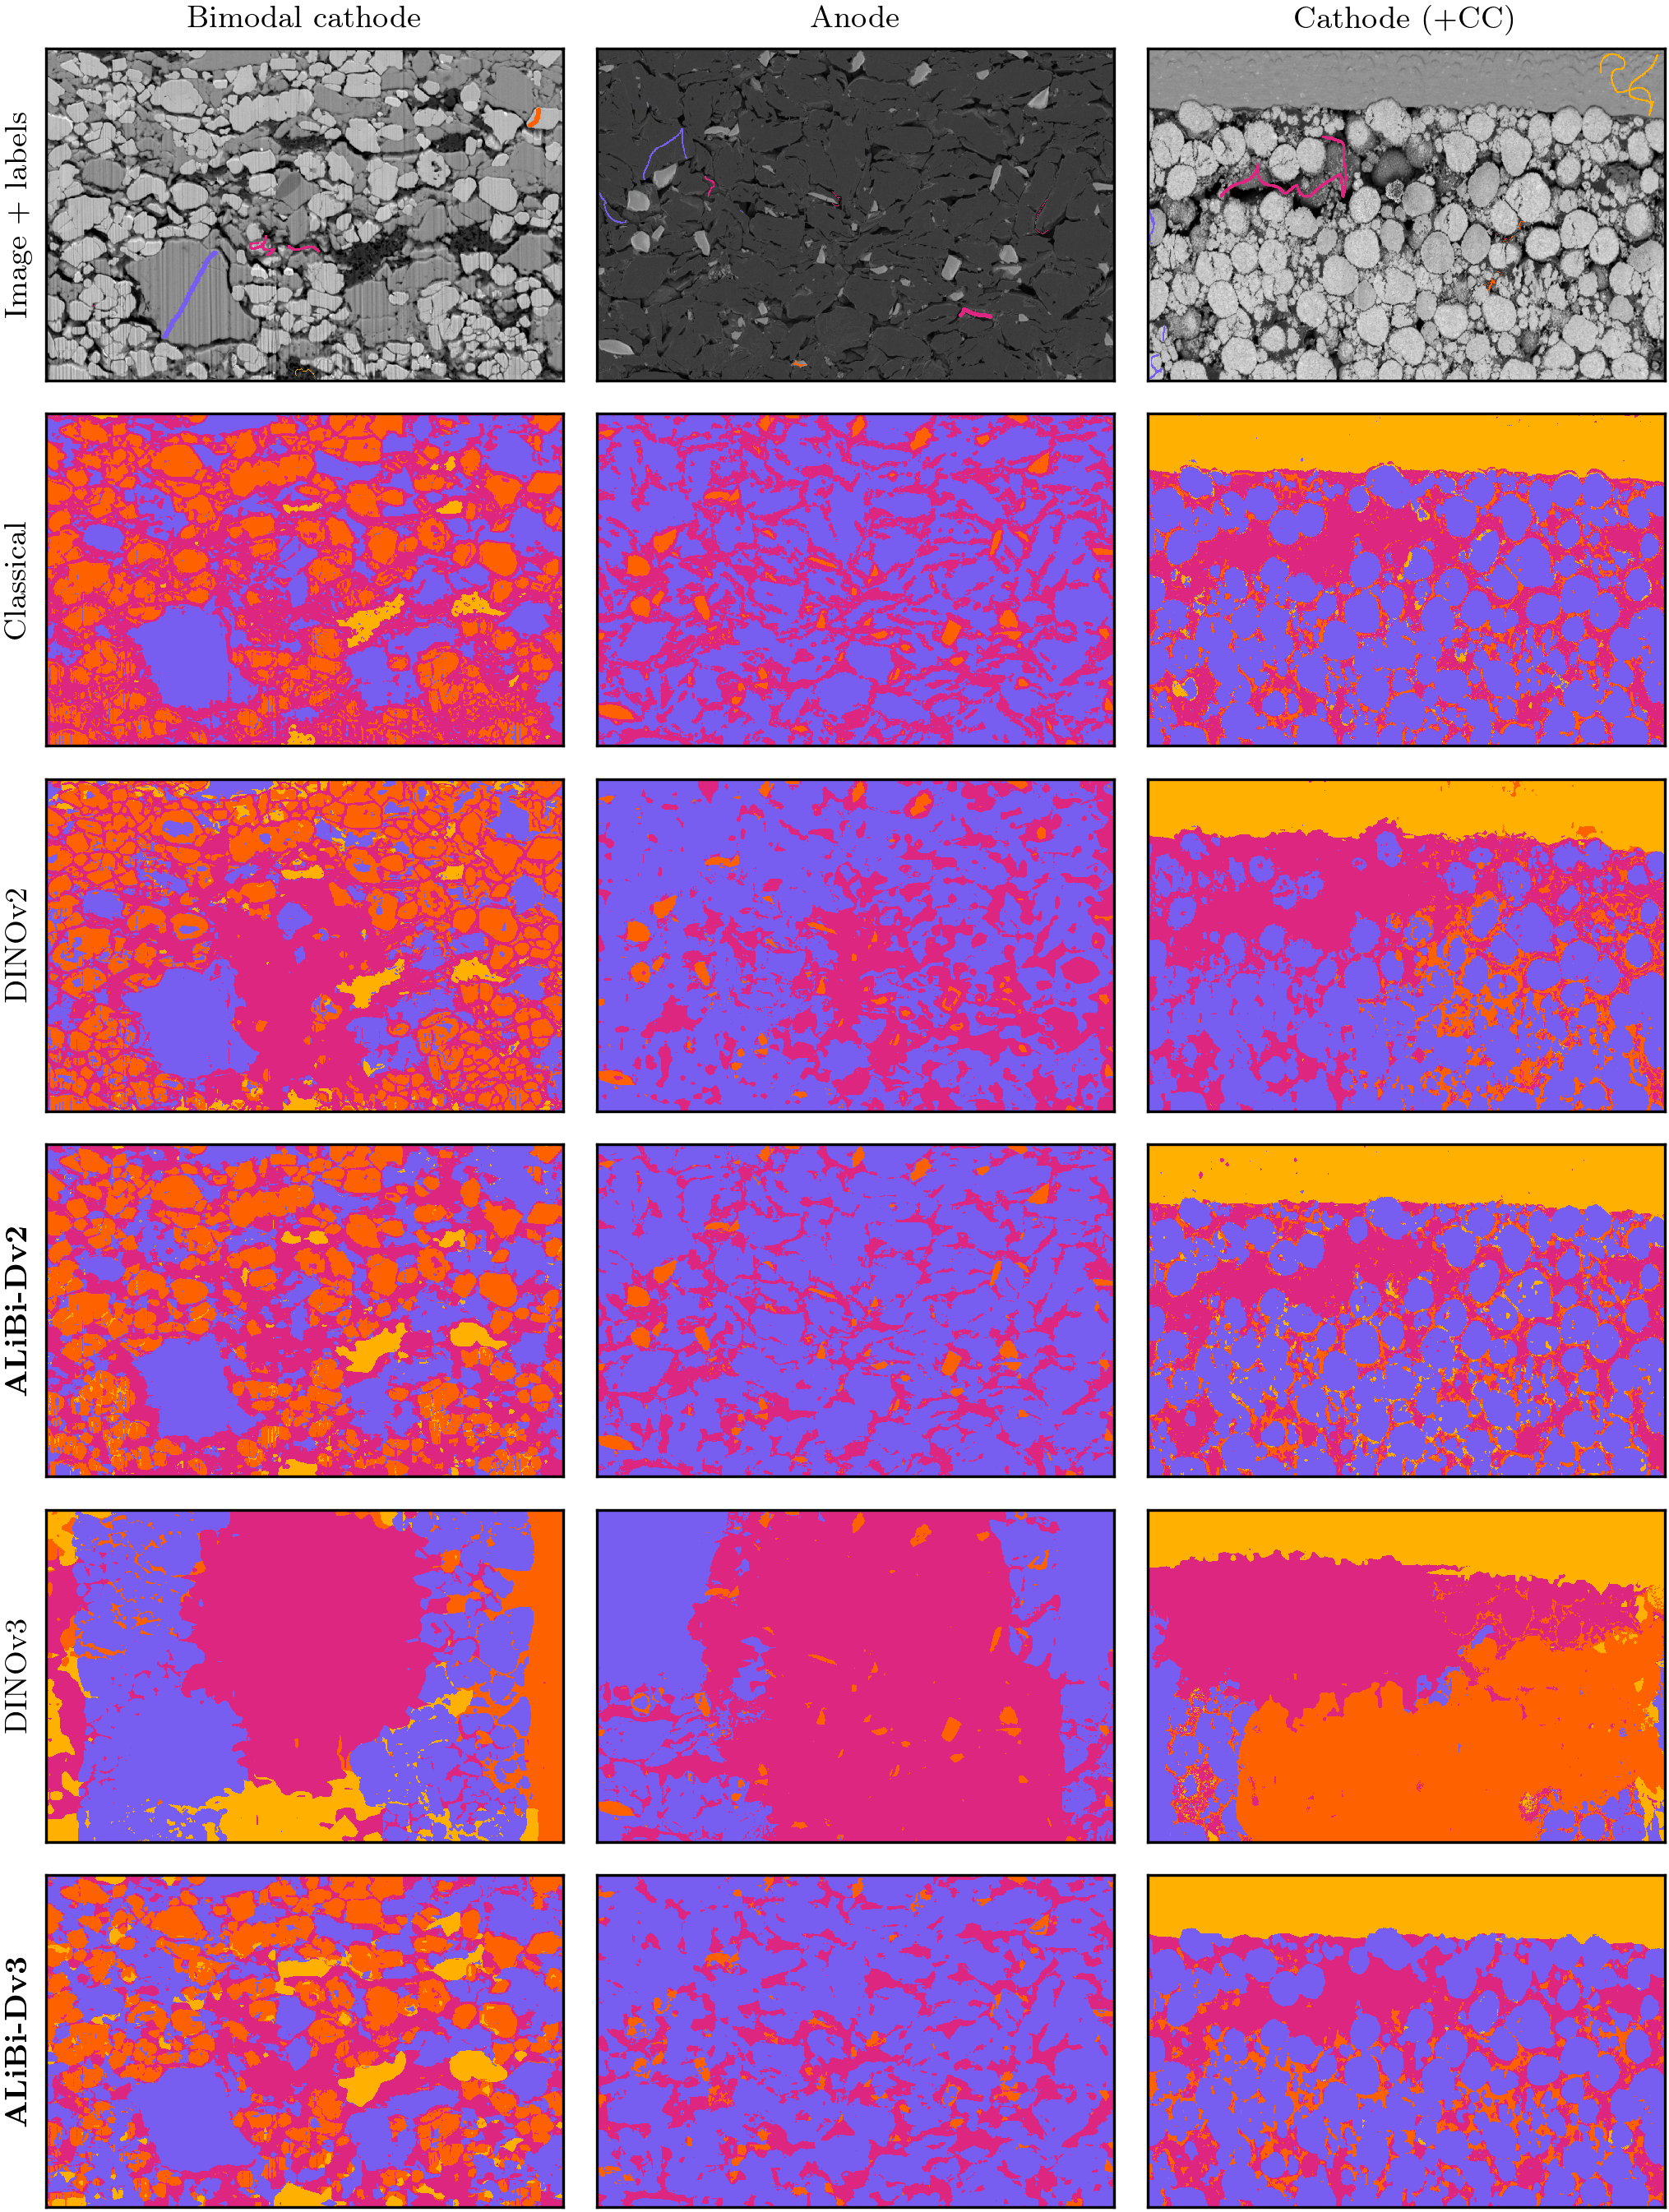

In [16]:
# %%capture
plt.style.use("thesis.mplstyle")
# W, H = 7, 2.3 * 3.25
W, H = 7, 2.3 * 4

N_ROWS = len(enabled_models) + 1
N_COLS = len(image_fnames)
fig, axs = plt.subplots(N_ROWS, N_COLS, figsize=(W, H))

titles = ["Bimodal cathode", "Anode", "Cathode (+CC)"]

for y in range(N_ROWS):
    for x in range(N_COLS):
        if y == 0:
            axs[y, 0].set_ylabel("Image + labels")
            axs[y, x].set_title(titles[x])
            arr = apply_labels_as_overlay(labels[x], images[x], COLORS, alpha=1)
        else:
            key = enabled_models[y-1]
            model_name = model_names[key]
            model_name = model_name.replace('(COCO)', '')
            model_name = rf"\textbf{{{model_name}}}" if 'alibi' in key.lower() else model_name
            axs[y, 0].set_ylabel(model_name)
            arr = preds[key][x]
            arr = label2rgb(arr + 1, colors=COLORS[1:], bg_label=0)
        axs[y, x].imshow(arr, aspect='auto', interpolation='nearest')
        hide_axis(axs[y, x])

plt.tight_layout()
plt.savefig('out/trainable_seg_.pdf', dpi=300, bbox_inches='tight')
# plt.close()
